# 1.0 Imports

### 1.1 Libs

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import inflection
import warnings
warnings.filterwarnings('ignore')
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from statsmodels.base.model import GenericLikelihoodModel

### 1.2 Functions

In [2]:
def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2))

def elasticity_gauss(P, mu, sigma):
    return -(P * (P - mu)) / (sigma**2)

### 1.3 Loading data

In [3]:
df_raw = pd.read_csv('../datasets/df_ready.csv', encoding='unicode_escape', low_memory=False)

In [4]:
df_raw.head().T

,0,1,2,3,4
Unnamed: 0,4,5,6,7,8
Date_imp,2017-12-14 06:00:00,2017-09-08 05:00:00,2017-10-24 04:00:00,2017-08-15 15:00:00,2017-09-14 21:00:00
Date_imp_d,2017/12/14,2017/09/08,2017/10/24,2017/08/15,2017/09/14
Cluster,35,35,35,35,35
Category_name,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth"
name,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...
price,69.0,69.0,66.0,74.99,69.99
disc_price,64.99,69.0,66.0,74.99,69.99
merchant,Walmart.com,Walmart.com,Walmart.com,Walmart.com,Walmart.com
condition,New,New,New,New,New


# 2.0 Descrição dos dados

In [5]:
df1 = df_raw.copy()

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23151 entries, 0 to 23150
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       23151 non-null  int64  
 1   Date_imp         23151 non-null  object 
 2   Date_imp_d       23151 non-null  object 
 3   Cluster          23151 non-null  int64  
 4   Category_name    23151 non-null  object 
 5   name             23151 non-null  object 
 6   price            23151 non-null  float64
 7   disc_price       23151 non-null  float64
 8   merchant         23151 non-null  object 
 9   condition        23151 non-null  object 
 10  Disc_percentage  23151 non-null  float64
 11  isSale           23151 non-null  object 
 12  Imp_count        23151 non-null  int64  
 13  brand            23151 non-null  object 
 14  p_description    23151 non-null  object 
 15  currency         23151 non-null  object 
 16  dateAdded        23151 non-null  object 
 17  dateSeen    

### 2.1 Renomear colunas

In [7]:
cols_old = ['Unnamed: 0', 'Date_imp', 'Date_imp_d', 'Cluster', 'Category_name', 'name', 'price', 'disc_price', 
       'merchant', 'condition', 'Disc_percentage', 'isSale', 'Imp_count', 'brand', 'p_description',
       'currency', 'dateAdded', 'dateSeen', 'dateUpdated', 'imageURLs', 'manufacturer', 'shipping', 'sourceURLs', 
       'weight', 'Date_imp_d.1', 'Day_n', 'month', 'month_n', 'day', 'Week_Number', 'Zscore_1', 'price_std']

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))
df1.columns = cols_new

### 2.2 Check NA

In [8]:
df1.isna().sum()

unnamed: 0             0
date_imp               0
date_imp_d             0
cluster                0
category_name          0
name                   0
price                  0
disc_price             0
merchant               0
condition              0
disc_percentage        0
is_sale                0
imp_count              0
brand                  0
p_description          0
currency               0
date_added             0
date_seen              0
date_updated           0
image_ur_ls        22696
manufacturer       10639
shipping           11497
source_ur_ls        4930
weight                68
date_imp_d.1           0
day_n                  0
month                  0
month_n                0
day                    0
week_number            0
zscore_1             171
price_std              0
dtype: int64

### 2.3 Linhas duplicadas

In [9]:
linhas_duplicadas = df1[df1.duplicated(keep=False)].index
print("Linhas duplicadas:")
print(linhas_duplicadas)

Linhas duplicadas:
Index([], dtype='int64')


### 2.4 Change types

In [10]:
df1['date_imp'] = pd.to_datetime(df1['date_imp'])
df1['date_added'] = pd.to_datetime(df1['date_added'])
#df1['date_seen'] = pd.to_datetime(df1['date_seen'])
df1['date_updated'] = pd.to_datetime(df1['date_updated'])

### 2.5 Estatística Descritiva

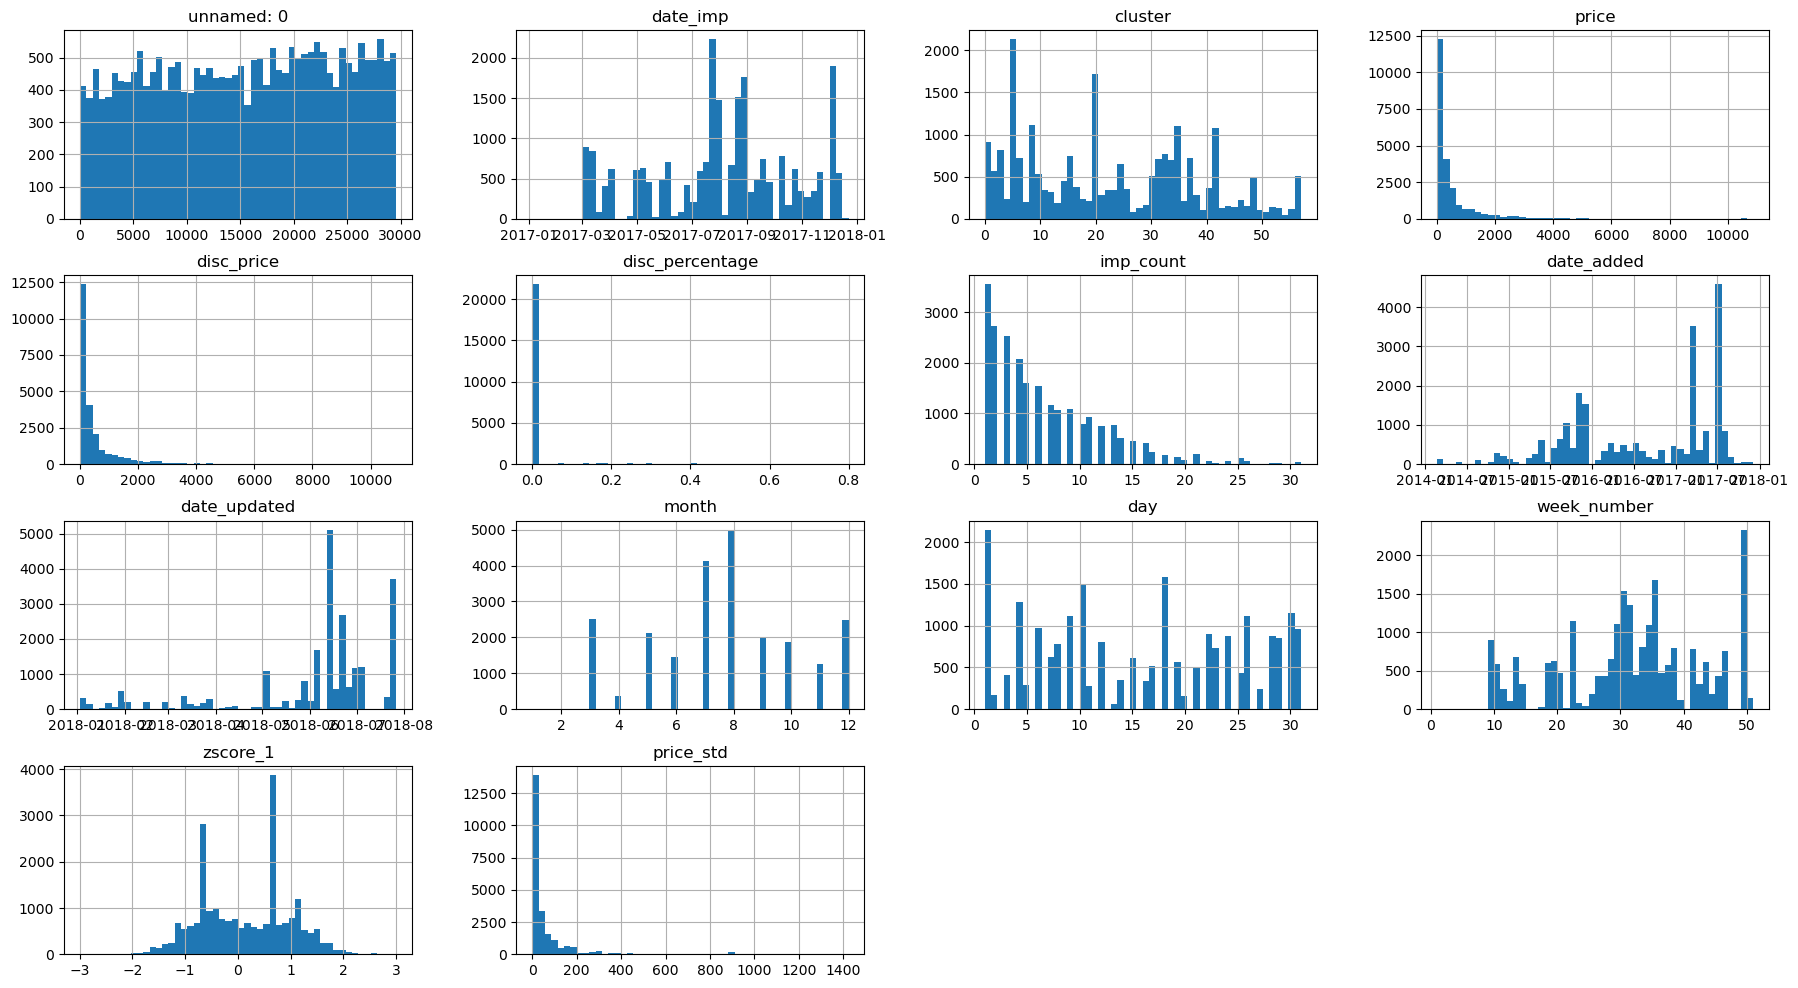

In [11]:
df1.hist(bins=50, figsize=(22,12));

In [12]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude =['int64', 'float64', 'datetime64[ns]'])

### 2.5.1 Atributos numéricos

In [13]:
stat_desc = df1.describe().T
stat_desc

,count,mean,min,25%,50%,75%,max,std
unnamed: 0,23151.0,15338.318431,4.0,7897.5,15613.0,22678.0,29592.0,8528.805636
date_imp,23151,2017-08-05 09:49:29.444084224,2017-01-05 00:00:00,2017-06-09 15:00:00,2017-08-10 00:00:00,2017-09-24 07:00:00,2017-12-22 06:00:00,NaN
cluster,23151.0,22.682735,0.0,8.0,20.0,35.0,57.0,15.576818
price,23151.0,513.037803,1.0,82.99,199.99,540.0,10879.95,859.110002
disc_price,23151.0,494.104295,1.0,79.99,199.0,516.49,10879.95,808.588973
disc_percentage,23151.0,0.016933,0.0,0.0,0.0,0.0,0.8,0.077849
imp_count,23151.0,6.560926,1.0,2.0,5.0,10.0,31.0,5.403166
month,23151.0,7.65103,1.0,6.0,8.0,9.0,12.0,2.592843
day,23151.0,15.693879,1.0,7.0,16.0,24.0,31.0,9.681622
week_number,23151.0,31.34275,1.0,23.0,32.0,38.0,51.0,11.316498


### 2.5.2 Atributos categóricos

In [14]:
cat_attributes.apply(lambda x: x.unique().shape[0])

date_imp_d        188
category_name      58
name              908
merchant            7
condition           1
is_sale             2
brand             266
p_description     908
currency            1
date_added        872
date_seen        4373
date_updated      819
image_ur_ls         5
manufacturer      236
shipping           69
source_ur_ls     3923
weight            640
date_imp_d.1      188
day_n               7
month_n            11
dtype: int64

### 2.6 Comparação das colunas 'price' e 'disc_price'

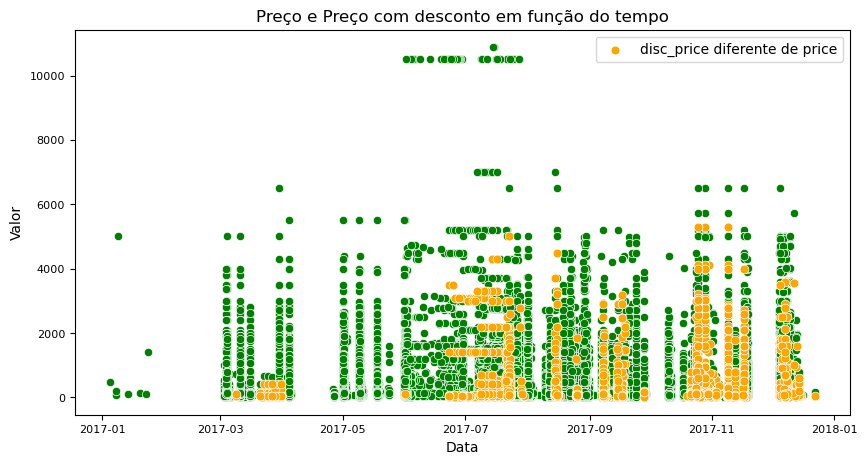

In [15]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df1, x='date_imp', y='price', color='green')
sns.scatterplot(data=df1[df1['price'] != df1['disc_price']], x='date_imp', y='disc_price',
    color='orange', s=40, marker='o', label='disc_price diferente de price')

plt.xlabel('Data')
plt.ylabel('Valor')
plt.title('Preço e Preço com desconto em função do tempo')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend()
plt.show()

### 2.7 Seleção de colunas

In [16]:
cols_drop = ['unnamed: 0', 'cluster', 'imp_count', 'zscore_1', 'price_std', 'date_imp_d', 'condition', 'is_sale',
            'currency', 'date_added', 'date_seen', 'date_updated', 'image_ur_ls', 'shipping', 'source_ur_ls', 
            'weight', 'date_imp_d.1']
df1 = df1.drop(cols_drop, axis=1)

In [17]:
df1.head().T

,0,1,2,3,4
date_imp,2017-12-14 06:00:00,2017-09-08 05:00:00,2017-10-24 04:00:00,2017-08-15 15:00:00,2017-09-14 21:00:00
category_name,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth"
name,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...
price,69.0,69.0,66.0,74.99,69.99
disc_price,64.99,69.0,66.0,74.99,69.99
merchant,Walmart.com,Walmart.com,Walmart.com,Walmart.com,Walmart.com
disc_percentage,0.06,0.0,0.0,0.0,0.0
brand,Boytone,Boytone,Boytone,Boytone,Boytone
p_description,"Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ..."
manufacturer,Boytone,Boytone,Boytone,Boytone,Boytone


# 3.0 Análise Exploratória dos Dados (EDA)

In [18]:
df2 = df1.copy()

### Quantidade de produtos vendidos por categoria

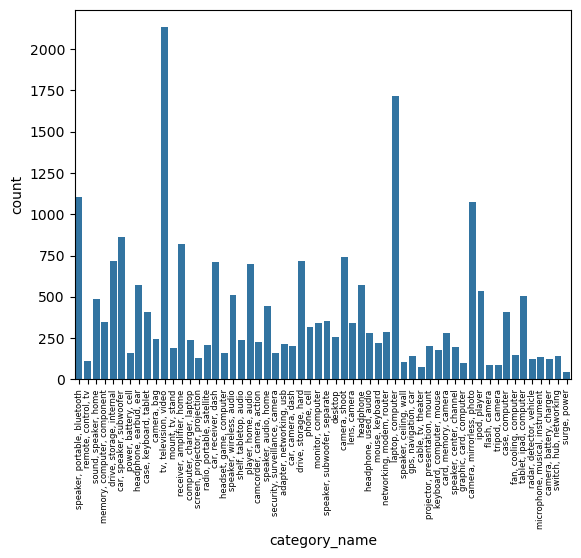

In [19]:
sns.countplot(data=df2, x='category_name');
plt.xticks(rotation=90)
plt.tick_params(axis='x', labelsize=6)
plt.show()

### Quantidade de produtos vendidos por marca para as categorias com maior número de vendas

In [20]:
aux = df2[df2['category_name'] == 'tv, television, video']
aux1 = df2[df2['category_name'] == 'laptop, computer']
aux2 = df2[df2['category_name'] == 'speaker, portable, bluetooth']

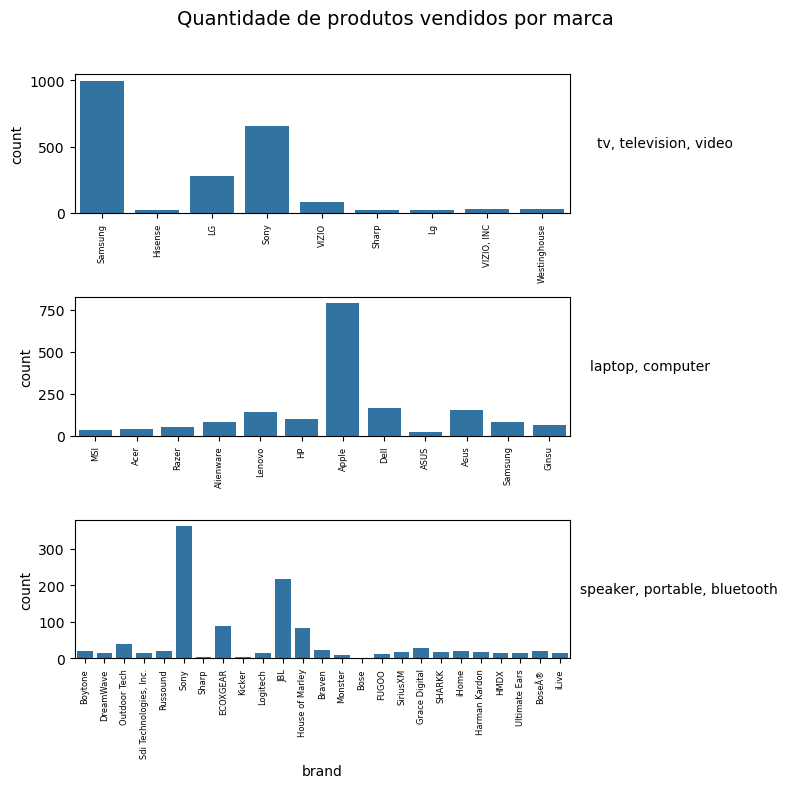

In [21]:
plt.figure(figsize=(8, 8))

plt.subplot(3, 1, 1)
sns.countplot(data=aux, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "tv, television, video", va="center", ha="left", fontsize=10)  # Colocar texto da categoria ao lado, centralizado verticalmente

plt.subplot(3, 1, 2)
sns.countplot(data=aux1, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "laptop, computer", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 3)
sns.countplot(data=aux2, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("brand")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "speaker, portable, bluetooth", va="center", ha="left", fontsize=10)

plt.suptitle("Quantidade de produtos vendidos por marca", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Quantidade de produtos vendidos por merchant para as categorias com maior número de vendas

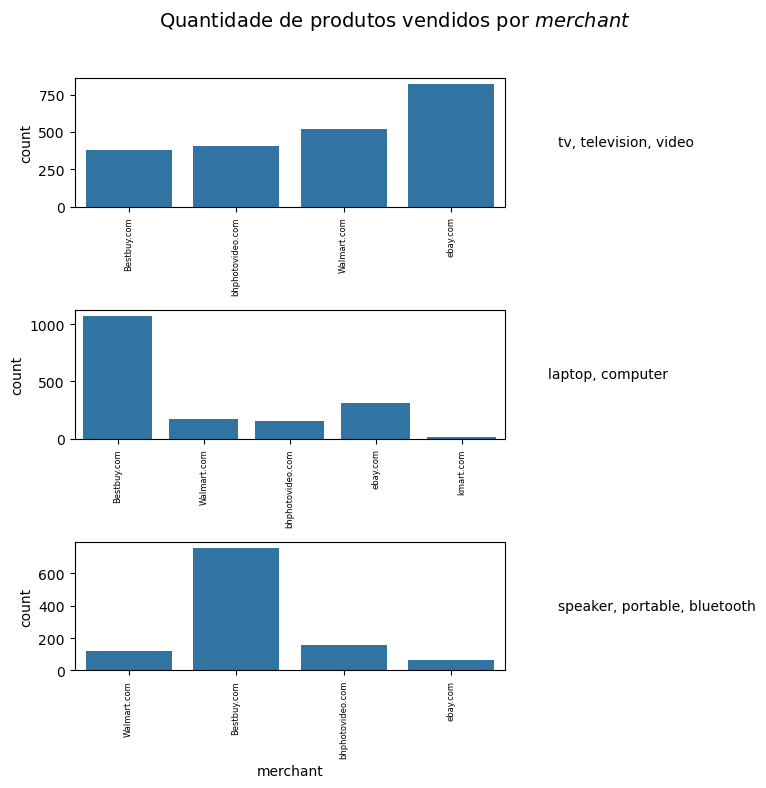

In [22]:
plt.figure(figsize=(8, 8))

plt.subplot(3, 1, 1)
sns.countplot(data=aux, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "tv, television, video", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 2)
sns.countplot(data=aux1, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "laptop, computer", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 3)
sns.countplot(data=aux2, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("merchant")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "speaker, portable, bluetooth", va="center", ha="left", fontsize=10)

plt.suptitle("Quantidade de produtos vendidos por $\t{merchant}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Para a categoria $laptop, computer$

In [23]:
aux = df2[(df2['category_name'] == 'laptop, computer') & (df2['merchant'] == 'Bestbuy.com')]
aux.head().T

,1792,1793,1794,1795,1796
date_imp,2017-06-29 22:00:00,2017-10-10 12:00:00,2017-09-12 04:00:00,2017-09-06 19:00:00,2017-08-30 08:00:00
category_name,"laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer"
name,MSI - WS Series 15.6 Laptop - Intel Core i7 - ...,MSI - WS Series 15.6 Laptop - Intel Core i7 - ...,MSI - WS Series 15.6 Laptop - Intel Core i7 - ...,MSI - WS Series 15.6 Laptop - Intel Core i7 - ...,MSI - WS Series 15.6 Laptop - Intel Core i7 - ...
price,2299.99,2399.99,2399.99,2399.99,2399.99
disc_price,2299.99,2399.99,2399.99,2399.99,2399.99
merchant,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com
disc_percentage,0.0,0.0,0.0,0.0,0.0
brand,MSI,MSI,MSI,MSI,MSI
p_description,"Computers,Computers & Accessories,Traditional ...","Computers,Computers & Accessories,Traditional ...","Computers,Computers & Accessories,Traditional ...","Computers,Computers & Accessories,Traditional ...","Computers,Computers & Accessories,Traditional ..."
manufacturer,NaN,NaN,NaN,NaN,NaN


In [24]:
# quantidade de cada produto dentro do categoria de laptop, computer
aux.groupby('name').count()

,date_imp,category_name,price,disc_price,merchant,disc_percentage,brand,p_description,manufacturer,day_n,month,month_n,day,week_number
name,,,,,,,,,,,,,,
"12 MacBook (Mid 2017, Gold)",25,25,25,25,25,25,25,25,0,25,25,25,25,25
"12 MacBook (Mid 2017, Silver)",10,10,10,10,10,10,10,10,10,10,10,10,10,10
12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,27,27,27,27,27,27,27,27,27,27,27,27,27,27
"13.3 MacBook Air (Mid 2017, Silver)",10,10,10,10,10,10,10,10,10,10,10,10,10,10
"15.4 MacBook Pro with Touch Bar (Late 2016, Silver)",30,30,30,30,30,30,30,30,30,30,30,30,30,30
"15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)",84,84,84,84,84,84,84,84,84,84,84,84,84,84
ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X,14,14,14,14,14,14,14,14,0,14,14,14,14,14
"Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray""",10,10,10,10,10,10,10,10,10,10,10,10,10,10
Acer 15.6 Chromebook CB5-571-C4G4,20,20,20,20,20,20,20,20,20,20,20,20,20,20


### Laptop, computer : estudo de Apple MacBook Pro with Touch Bar - 13.3 - Core i5 - 8 GB RAM - 512 GB SSD - English
### Merchant escolhido: Bestbuy.com

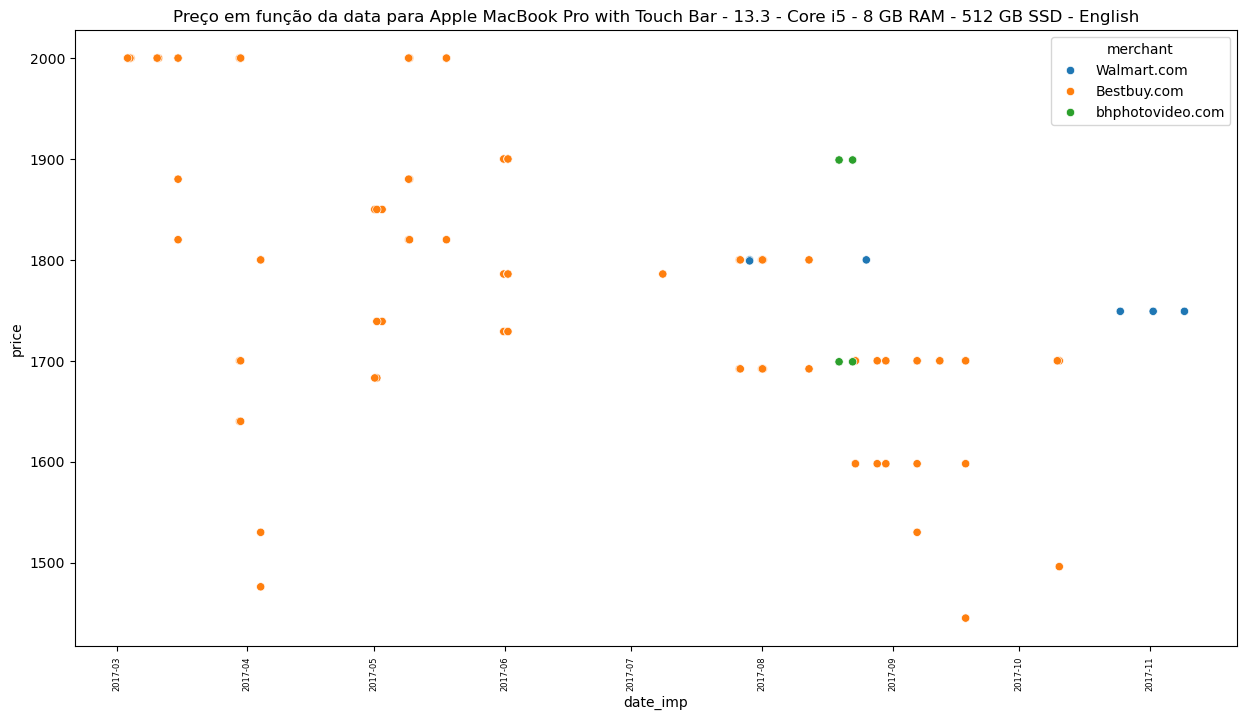

In [25]:
aux = df2[(df2['category_name'] == 'laptop, computer') & (df2['name'] == 'Apple MacBook Pro with Touch Bar - 13.3 - Core i5 - 8 GB RAM - 512 GB SSD - English"')]

plt.figure(figsize=(15, 8))
sns.scatterplot(x='date_imp', y='price', data=aux, hue='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.title('Preço em função da data para Apple MacBook Pro with Touch Bar - 13.3 - Core i5 - 8 GB RAM - 512 GB SSD - English')
plt.show;

In [26]:
aux1 = df2[(df2['category_name'] == 'laptop, computer') & (df2['merchant'] == 'Bestbuy.com') & (df2['name'] == 'Apple MacBook Pro with Touch Bar - 13.3 - Core i5 - 8 GB RAM - 512 GB SSD - English"')]
aux1.T

,10947,10948,10949,10950,10951,10952,10953,10954,10955,10956,...,11030,11031,11032,11033,11034,11035,11036,11037,11038,11039
date_imp,2017-10-10 12:00:00,2017-09-12 04:00:00,2017-09-06 19:00:00,2017-08-30 09:00:00,2017-09-18 07:00:00,2017-08-23 04:00:00,2017-08-28 08:00:00,2017-03-30 04:00:00,2017-03-30 10:00:00,2017-10-10 12:00:00,...,2017-05-01 05:00:00,2017-10-10 12:00:00,2017-05-09 11:00:00,2017-05-09 06:00:00,2017-03-15 14:00:00,2017-05-02 23:00:00,2017-05-01 17:00:00,2017-04-04 04:00:00,2017-03-30 04:00:00,2017-03-30 10:00:00
category_name,"laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer",...,"laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer","laptop, computer"
name,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...,Apple MacBook Pro with Touch Bar - 13.3 - Core...
price,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,...,1682.99,1495.99,1879.99,1879.99,1879.99,1738.99,1738.99,1475.99,1639.99,1639.99
disc_price,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,1699.99,...,1682.99,1495.99,1879.99,1879.99,1879.99,1738.99,1738.99,1475.99,1639.99,1639.99
merchant,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,...,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com
disc_percentage,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
brand,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,...,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple
p_description,"Walmart for Business,Office Electronics,Comput...","Walmart for Business,Office Electronics,Comput...","Walmart for Business,Office Electronics,Comput...","Walmart for Business,Office Electronics,Comput...","Walmart for Business,Office Electronics,Comput...","Walmart for Business,Office Electronics,Comput...","Walmart for Business,Office Electronics,Comput...","Walmart for Business,Office Electronics,Comput...","Walmart for Business,Office Electronics,Comput...","Electronics,Computers,Laptops,Shop Laptops by ...",...,"Walmart for Business,Office Electronics,Comput...","Electronics,Computers,Laptops,Shop Laptops by ...","Electronics,Computers,Laptops,Shop Laptops by ...","Electronics,Computers,Laptops,Shop Laptops by ...","Electronics,Computers,Laptops,Shop Laptops by ...","Electronics,Computers,Laptops,Shop Laptops by ...","Electronics,Computers,Laptops,Shop Laptops by ...","Electronics,Computers,Laptops,Shop Laptops by ...","Electronics,Computers,Laptops,Shop Laptops by ...","Electronics,Computers,Laptops,Shop Laptops by ..."
manufacturer,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,...,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple,Apple


### Determinando a demanda (ou quantidade vendida)

In [27]:
# neste caso, a demanda é a quantidade de produtos vendidos em determinado preço

In [28]:
df_demanda= aux1.groupby('price')['name'].count().reset_index(name='quantidade')

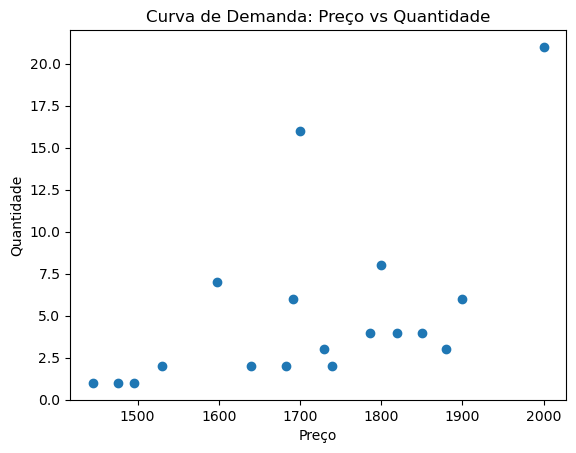

In [29]:
plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

### Determinando preço ótimo

In [30]:
# Preço ótimo - preço que resulta na maior receita conforme a demanda observada
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price          1999.99
quantidade       21.00
receita       41999.79
Name: 17, dtype: float64


In [31]:
df_demanda.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
price,1444.99,1475.99,1495.99,1529.99,1597.99,1639.99,1682.99,1691.99,1699.99,1728.99,1738.99,1785.99,1799.99,1819.99,1849.99,1879.99,1899.99,1999.99
quantidade,1.00,1.00,1.00,2.00,7.00,2.00,2.00,6.00,16.00,3.00,2.00,4.00,8.00,4.00,4.00,3.00,6.00,21.00
receita,1444.99,1475.99,1495.99,3059.98,11185.93,3279.98,3365.98,10151.94,27199.84,5186.97,3477.98,7143.96,14399.92,7279.96,7399.96,5639.97,11399.94,41999.79


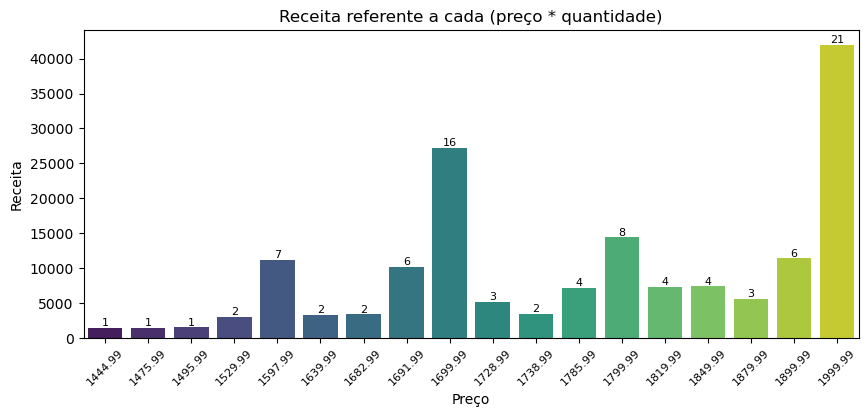

In [32]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

### Determinando a elasticidade

In [33]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     6.456
Date:                Tue, 23 Sep 2025   Prob (F-statistic):             0.0218
Time:                        21:22:26   Log-Likelihood:                -52.162
No. Observations:                  18   AIC:                             108.3
Df Residuals:                      16   BIC:                             110.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.1095     12.

### Determinando a curva resposta

In [34]:
# curva resposta - Modelo linear
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 1999.99  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 1399.99, Quantidade: -0.49, Elasticidade: -52.292
Preço: 1599.99, Quantidade: 3.17, Elasticidade: 9.236
Preço: 1799.99, Quantidade: 6.83, Elasticidade: 4.823
Preço: 1999.99, Quantidade: 10.49, Elasticidade: 3.489
Preço: 2199.99, Quantidade: 14.15, Elasticidade: 2.845
Preço: 2399.99, Quantidade: 17.81, Elasticidade: 2.466
Preço: 2599.99, Quantidade: 21.47, Elasticidade: 2.216


In [35]:
# como os resultados de R^2 e p-valor mostram, no modelo linear, o preço não explica de 
# maneira relevante e significativa a variação apresentada pela demanda. logo, o resultado da elasticidade
# fornecida pelo modelo bem como a curva resposta devem ser usados com parcimônia.

In [36]:
# curva resposta - Modelo log-log
alpha = model_log.params['const']
beta = model_log.params['price']

preco_otimo = 1999.99  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  

for v in variacoes:
    P = preco_otimo * v
    Q = np.exp(alpha) * (P ** beta)  # previsão no modelo log-log
    E = beta  # elasticidade constante
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 1399.99, Quantidade: 0.95, Elasticidade: 6.664
Preço: 1599.99, Quantidade: 2.32, Elasticidade: 6.664
Preço: 1799.99, Quantidade: 5.08, Elasticidade: 6.664
Preço: 1999.99, Quantidade: 10.25, Elasticidade: 6.664
Preço: 2199.99, Quantidade: 19.34, Elasticidade: 6.664
Preço: 2399.99, Quantidade: 34.54, Elasticidade: 6.664
Preço: 2599.99, Quantidade: 58.89, Elasticidade: 6.664


### Merchant escolhido: Walmart.com

In [37]:
aux31 = df2[(df2['category_name'] == 'laptop, computer') & (df2['merchant'] == 'Walmart.com') & (df2['name'] == 'Apple MacBook Pro with Touch Bar - 13.3 - Core i5 - 8 GB RAM - 512 GB SSD - English"')]

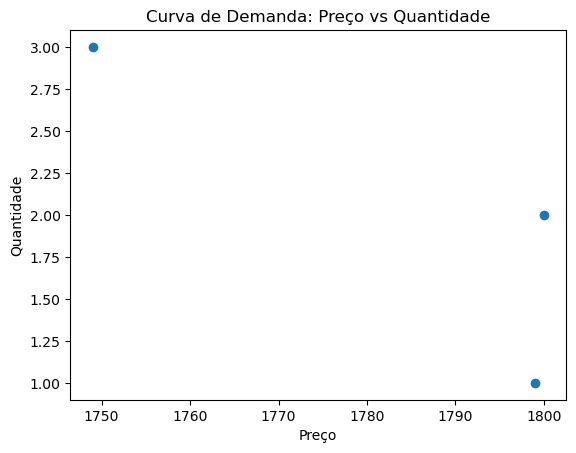

In [38]:
df_demanda= aux31.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [39]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price         1749.0
quantidade       3.0
receita       5247.0
Name: 0, dtype: float64


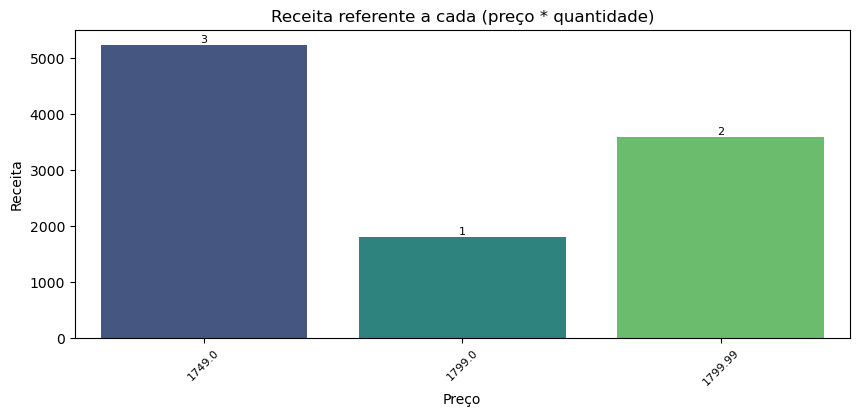

In [40]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [41]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     2.776
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.344
Time:                        21:22:28   Log-Likelihood:                -1.6557
No. Observations:                   3   AIC:                             7.311
Df Residuals:                       1   BIC:                             5.509
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         54.4214     31.

In [42]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 1749.0  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 1224.30, Quantidade: 18.42, Elasticidade: -1.955
Preço: 1399.20, Quantidade: 13.28, Elasticidade: -3.099
Preço: 1574.10, Quantidade: 8.13, Elasticidade: -5.691
Preço: 1749.00, Quantidade: 2.99, Elasticidade: -17.202
Preço: 1923.90, Quantidade: -2.15, Elasticidade: 26.274
Preço: 2098.80, Quantidade: -7.30, Elasticidade: 8.459
Preço: 2273.70, Quantidade: -12.44, Elasticidade: 5.375


In [43]:
# resultados de R^2 e p-valor melhores que nos anteriores mas o p-valor mostra que o resultado obtido 
# não é estatisticamente significante.

### Merchant escolhido: bhphotovideo.com

In [44]:
aux41 = df2[(df2['category_name'] == 'laptop, computer') & (df2['merchant'] == 'bhphotovideo.com') & (df2['name'] == 'Apple MacBook Pro with Touch Bar - 13.3 - Core i5 - 8 GB RAM - 512 GB SSD - English"')]

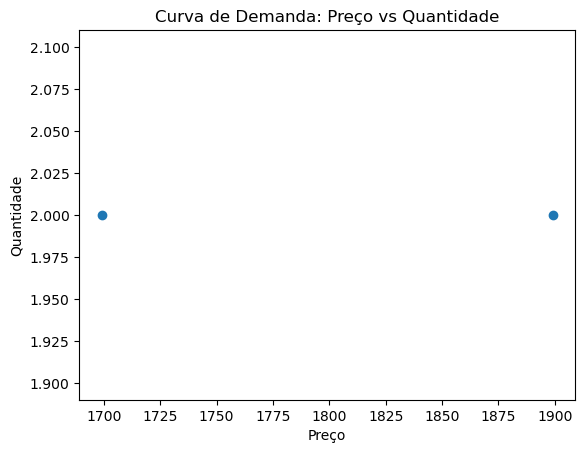

In [45]:
df_demanda= aux41.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [46]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price         1899.0
quantidade       2.0
receita       3798.0
Name: 1, dtype: float64


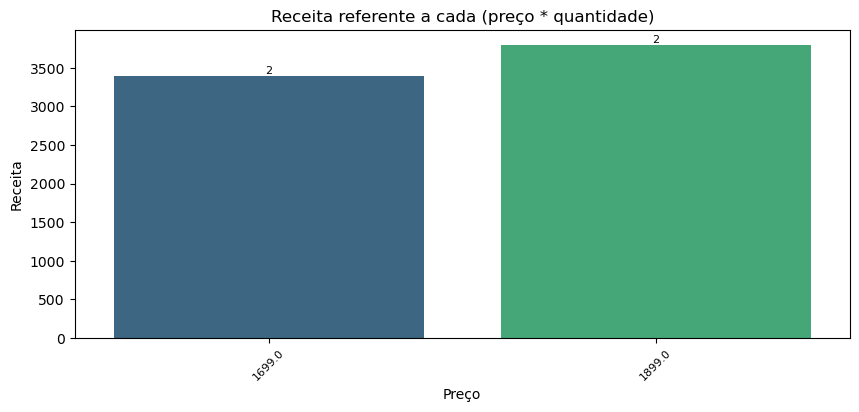

In [47]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [48]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 23 Sep 2025   Prob (F-statistic):                nan
Time:                        21:22:29   Log-Likelihood:                    inf
No. Observations:                   2   AIC:                              -inf
Df Residuals:                       0   BIC:                              -inf
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0000        

In [49]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 3498.0  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 2448.60, Quantidade: 2.00, Elasticidade: 0.000
Preço: 2798.40, Quantidade: 2.00, Elasticidade: 0.000
Preço: 3148.20, Quantidade: 2.00, Elasticidade: 0.000
Preço: 3498.00, Quantidade: 2.00, Elasticidade: 0.000
Preço: 3847.80, Quantidade: 2.00, Elasticidade: 0.000
Preço: 4197.60, Quantidade: 2.00, Elasticidade: 0.000
Preço: 4547.40, Quantidade: 2.00, Elasticidade: 0.000


In [50]:
# como os resultados de R^2 e p-valor mostram, tanto no modelo linear quanto no log, o preço não explica de 
# maneira relevante e significativa a variação apresentada pela demanda. logo, os resultados das elasticidades
# fornecidas pelos modelos bem como as curvas respostas devem ser usados com parcimônia.

### Merchant escolhido: Bestbuy.com, Walmart.com, bhphotovideo.com

In [51]:
aux51 = df2[(df2['category_name'] == 'laptop, computer') & (df2['name'] == 'Apple MacBook Pro with Touch Bar - 13.3 - Core i5 - 8 GB RAM - 512 GB SSD - English"')]

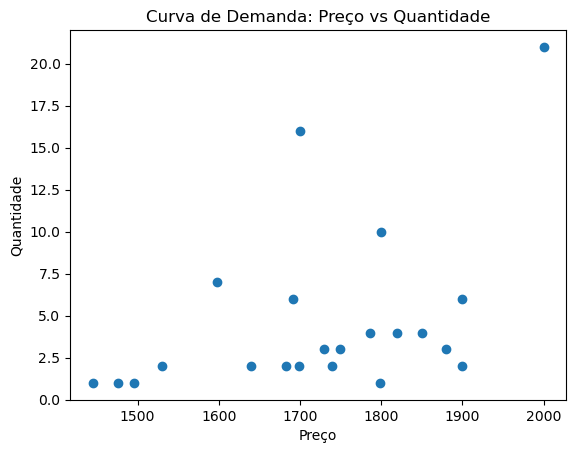

In [52]:
df_demanda= aux51.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [53]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price          1999.99
quantidade       21.00
receita       41999.79
Name: 21, dtype: float64


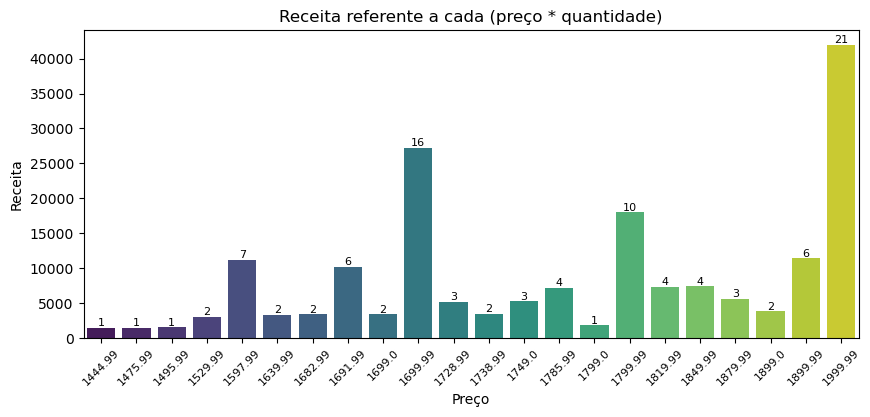

In [54]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [55]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     4.843
Date:                Tue, 23 Sep 2025   Prob (F-statistic):             0.0397
Time:                        21:22:30   Log-Likelihood:                -64.012
No. Observations:                  22   AIC:                             132.0
Df Residuals:                      20   BIC:                             134.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -21.3812     11.

In [56]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 2749.52  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 1924.66, Quantidade: 7.73, Elasticidade: 3.766
Preço: 2199.62, Quantidade: 11.89, Elasticidade: 2.799
Preço: 2474.57, Quantidade: 16.05, Elasticidade: 2.332
Preço: 2749.52, Quantidade: 20.21, Elasticidade: 2.058
Preço: 3024.47, Quantidade: 24.36, Elasticidade: 1.878
Preço: 3299.42, Quantidade: 28.52, Elasticidade: 1.750
Preço: 3574.38, Quantidade: 32.68, Elasticidade: 1.654


In [57]:
# curva resposta - Modelo log-log
alpha = model_log.params['const']
beta = model_log.params['price']

preco_otimo = 2749.52  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  

for v in variacoes:
    P = preco_otimo * v
    Q = np.exp(alpha) * (P ** beta)  # previsão no modelo log-log
    E = beta  # elasticidade constante
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 1924.66, Quantidade: 5.87, Elasticidade: 5.445
Preço: 2199.62, Quantidade: 12.15, Elasticidade: 5.445
Preço: 2474.57, Quantidade: 23.07, Elasticidade: 5.445
Preço: 2749.52, Quantidade: 40.95, Elasticidade: 5.445
Preço: 3024.47, Quantidade: 68.80, Elasticidade: 5.445
Preço: 3299.42, Quantidade: 110.50, Elasticidade: 5.445
Preço: 3574.38, Quantidade: 170.87, Elasticidade: 5.445


## Análise com regressão não linear

In [61]:
preco = df_demanda['price'].values
quantidade = df_demanda['quantidade'].values

# curve_fit
p0 = [quantidade.max(), np.median(preco), np.std(preco)]
popt, pcov = curve_fit(gauss, preco, quantidade, p0=p0, maxfev=90000)
a_cf, mu_cf, sigma_cf = popt
se_cf = np.sqrt(np.diag(pcov))

# statsmodels (GenericLikelihoodModel)
class GaussModel(GenericLikelihoodModel):
    def nloglikeobs(self, params):
        a, mu, sigma = params
        yhat = gauss(preco, a, mu, sigma)
        resid = quantidade - yhat
        sigma_res = np.std(resid)
        return 0.5 * np.log(2*np.pi) + np.log(sigma_res) + 0.5*(resid/sigma_res)**2

mod = GaussModel(quantidade)
mod.endog_index = preco
res = mod.fit(start_params=p0, method="bfgs", disp=False, maxiter=10000)
a_sm, mu_sm, sigma_sm = res.params

# Elasticidades
df_demanda['elasticidade_curvefit'] = elasticity_gauss(df_demanda['price'], mu_cf, sigma_cf)
df_demanda['elasticidade_statsmodels'] = elasticity_gauss(df_demanda['price'], mu_sm, sigma_sm)

print("curve_fit params:", popt, "std err:", se_cf)
print(res.summary())

curve_fit params: [2.69847945e+129 1.04170518e+005 4.20416969e+003] std err: [3.81156295e+134 4.90802784e+007 1.00839133e+006]
                              GaussModel Results                              
Dep. Variable:                      y   Log-Likelihood:                -62.572
Model:                     GaussModel   AIC:                             137.1
Method:            Maximum Likelihood   BIC:                             143.7
Date:                Tue, 23 Sep 2025                                         
Time:                        21:30:16                                         
No. Observations:                  22                                         
Df Residuals:                      19                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0

In [ ]:
# análise não linear gaussiana não se aplica para esse conjunto de dados. para maxfev >= 90000, o programa roda 
# mas gera valores extremamente altos para os coeficientes (não condizentes com o problema em questão) e
# erros ainda maiores que os coeficientes. 

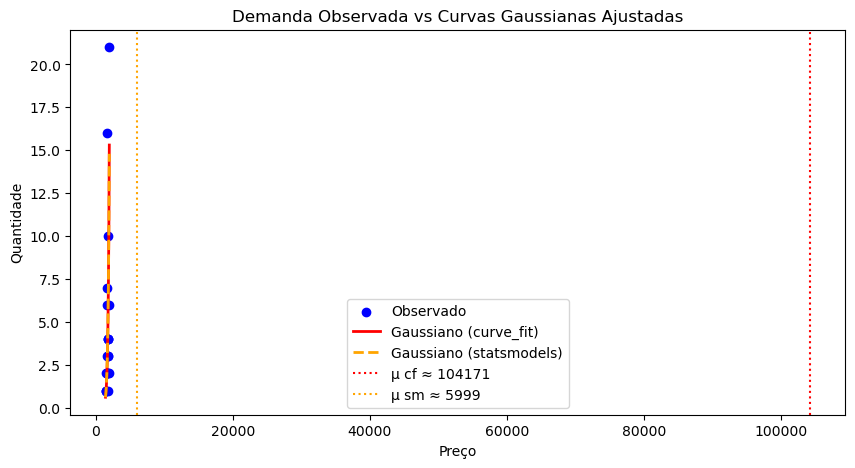

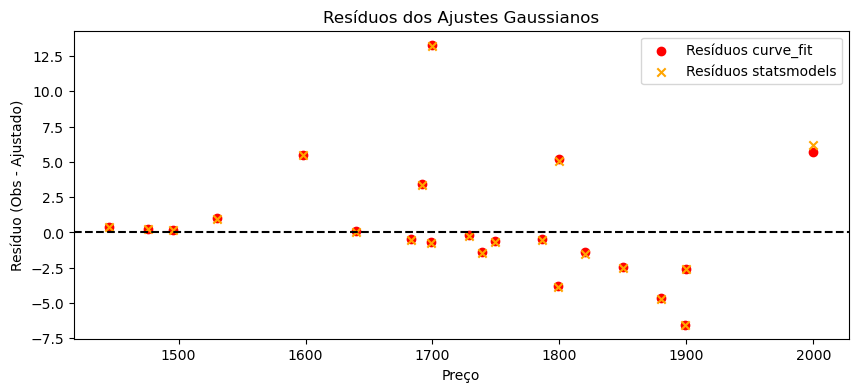

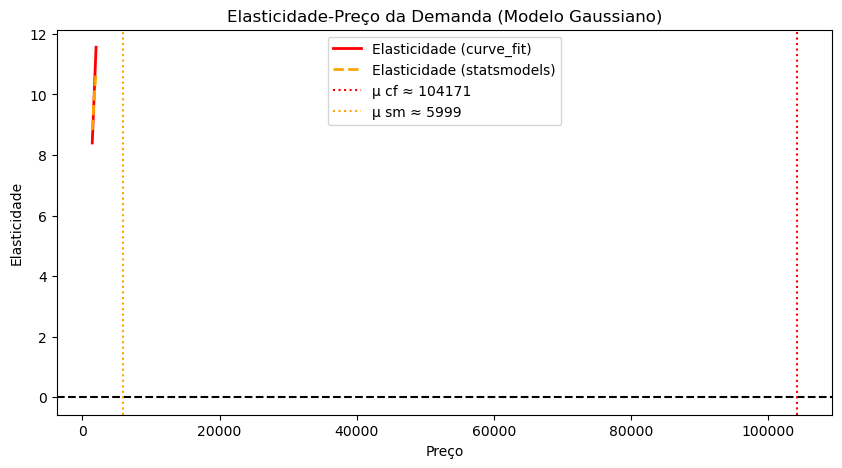

In [62]:
# Parâmetros estimados
a_cf, mu_cf, sigma_cf = popt  # do curve_fit
a_sm, mu_sm, sigma_sm = res.params  # do statsmodels

# Grid de preços para curvas suaves
preco_grid = np.linspace(df_demanda['price'].min(), df_demanda['price'].max(), 300)

# Previsões
q_pred_cf = gauss(preco_grid, a_cf, mu_cf, sigma_cf)
q_pred_sm = gauss(preco_grid, a_sm, mu_sm, sigma_sm)

# 1. Curva ajustada vs dados
plt.figure(figsize=(10,5))
plt.scatter(df_demanda['price'], df_demanda['quantidade'], color="blue", label="Observado")
plt.plot(preco_grid, q_pred_cf, color="red", linewidth=2, label="Gaussiano (curve_fit)")
plt.plot(preco_grid, q_pred_sm, color="orange", linestyle="--", linewidth=2, label="Gaussiano (statsmodels)")
plt.axvline(mu_cf, color="red", linestyle=":", label=f"μ cf ≈ {mu_cf:.0f}")
plt.axvline(mu_sm, color="orange", linestyle=":", label=f"μ sm ≈ {mu_sm:.0f}")
plt.title("Demanda Observada vs Curvas Gaussianas Ajustadas")
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

# 2. Resíduos
q_fit_cf = gauss(df_demanda['price'], a_cf, mu_cf, sigma_cf)
q_fit_sm = gauss(df_demanda['price'], a_sm, mu_sm, sigma_sm)
residuos_cf = df_demanda['quantidade'] - q_fit_cf
residuos_sm = df_demanda['quantidade'] - q_fit_sm

plt.figure(figsize=(10,4))
plt.axhline(0, color="black", linestyle="--")
plt.scatter(df_demanda['price'], residuos_cf, color="red", label="Resíduos curve_fit")
plt.scatter(df_demanda['price'], residuos_sm, color="orange", marker="x", label="Resíduos statsmodels")
plt.title("Resíduos dos Ajustes Gaussianos")
plt.xlabel("Preço")
plt.ylabel("Resíduo (Obs - Ajustado)")
plt.legend()
plt.show()

# 3. Elasticidade vs preço
elasticidade_cf = elasticity_gauss(preco_grid, mu_cf, sigma_cf)
elasticidade_sm = elasticity_gauss(preco_grid, mu_sm, sigma_sm)

plt.figure(figsize=(10,5))
plt.plot(preco_grid, elasticidade_cf, color="red", linewidth=2, label="Elasticidade (curve_fit)")
plt.plot(preco_grid, elasticidade_sm, color="orange", linestyle="--", linewidth=2, label="Elasticidade (statsmodels)")
plt.axhline(0, color="black", linestyle="--")
plt.axvline(mu_cf, color="red", linestyle=":", label=f"μ cf ≈ {mu_cf:.0f}")
plt.axvline(mu_sm, color="orange", linestyle=":", label=f"μ sm ≈ {mu_sm:.0f}")
plt.title("Elasticidade-Preço da Demanda (Modelo Gaussiano)")
plt.xlabel("Preço")
plt.ylabel("Elasticidade")
plt.legend()
plt.show()

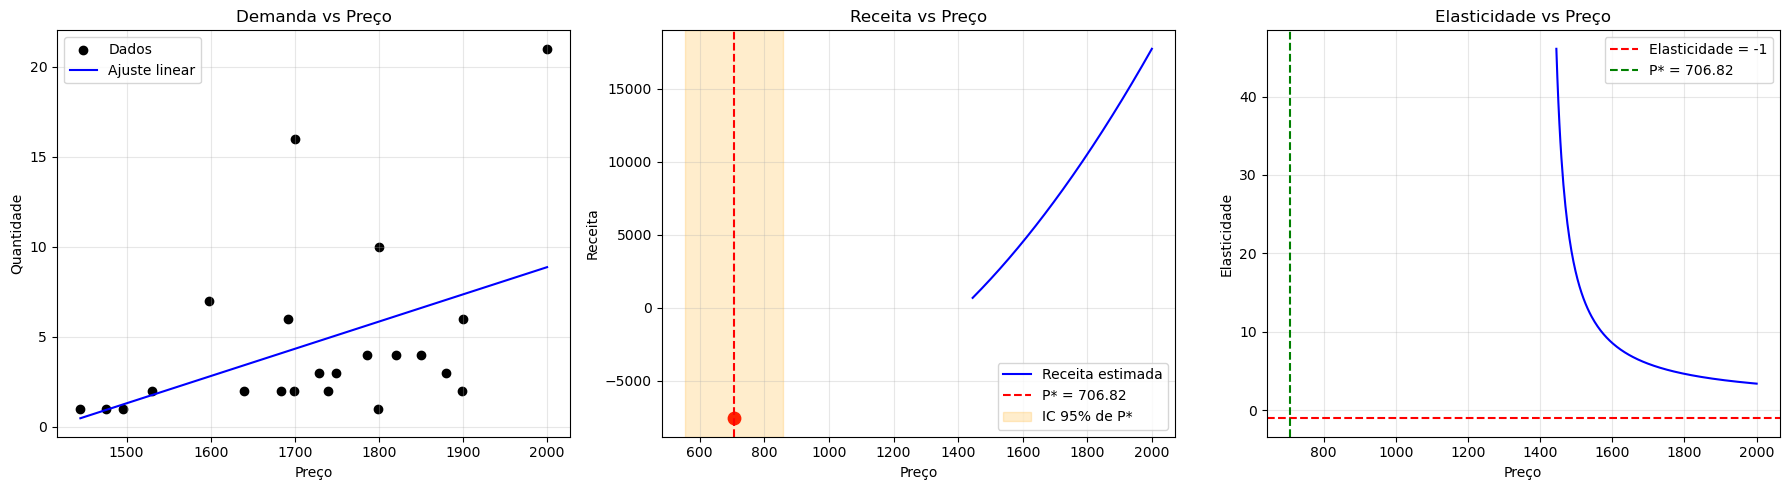

Resultados do ajuste linear:
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     4.843
Date:                Tue, 23 Sep 2025   Prob (F-statistic):             0.0397
Time:                        21:30:36   Log-Likelihood:                -64.012
No. Observations:                  22   AIC:                             132.0
Df Residuals:                      20   BIC:                             134.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -21.3812  

In [63]:
X = sm.add_constant(df_demanda['price'])
y = df_demanda['quantidade']
model = sm.OLS(y, X).fit()

# Coeficientes da regressão
beta0, beta1 = model.params

# Preço ótimo (maximiza a receita)
P_star = -beta0 / (2 * beta1)

# Gradiente para delta method
grad = np.array([-1 / (2 * beta1), beta0 / (2 * beta1**2)])
cov = model.cov_params()
var_Pstar = grad.T @ cov @ grad
se_Pstar = np.sqrt(var_Pstar)
ci_low, ci_high = P_star - 1.96 * se_Pstar, P_star + 1.96 * se_Pstar

precos = np.linspace(df_demanda['price'].min(), df_demanda['price'].max(), 200)
quantidades_pred = beta0 + beta1 * precos
receita = precos * quantidades_pred
elasticidade = beta1 * (precos / quantidades_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Demanda
axes[0].scatter(df_demanda['price'], df_demanda['quantidade'], label="Dados", color="black")
axes[0].plot(precos, quantidades_pred, color="blue", label="Ajuste linear")
axes[0].set_title("Demanda vs Preço")
axes[0].set_xlabel("Preço")
axes[0].set_ylabel("Quantidade")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Receita
axes[1].plot(precos, receita, color="blue", label="Receita estimada")
axes[1].axvline(P_star, color="red", linestyle="--", label=f"P* = {P_star:.2f}")
axes[1].scatter(P_star, P_star * (beta0 + beta1 * P_star), color="red", s=80)
axes[1].axvspan(ci_low, ci_high, color="orange", alpha=0.2, label="IC 95% de P*")
axes[1].set_title("Receita vs Preço")
axes[1].set_xlabel("Preço")
axes[1].set_ylabel("Receita")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Elasticidade
axes[2].plot(precos, elasticidade, color="blue")
axes[2].axhline(-1, color="red", linestyle="--", label="Elasticidade = -1")
axes[2].axvline(P_star, color="green", linestyle="--", label=f"P* = {P_star:.2f}")
axes[2].set_title("Elasticidade vs Preço")
axes[2].set_xlabel("Preço")
axes[2].set_ylabel("Elasticidade")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Resultados do ajuste linear:")
print(model.summary())
print(f"\nPreço ótimo (P*): {P_star:.2f}")
print(f"Erro-padrão de P*: {se_Pstar:.2f}")
print(f"IC 95% para P*: [{ci_low:.2f}, {ci_high:.2f}]")

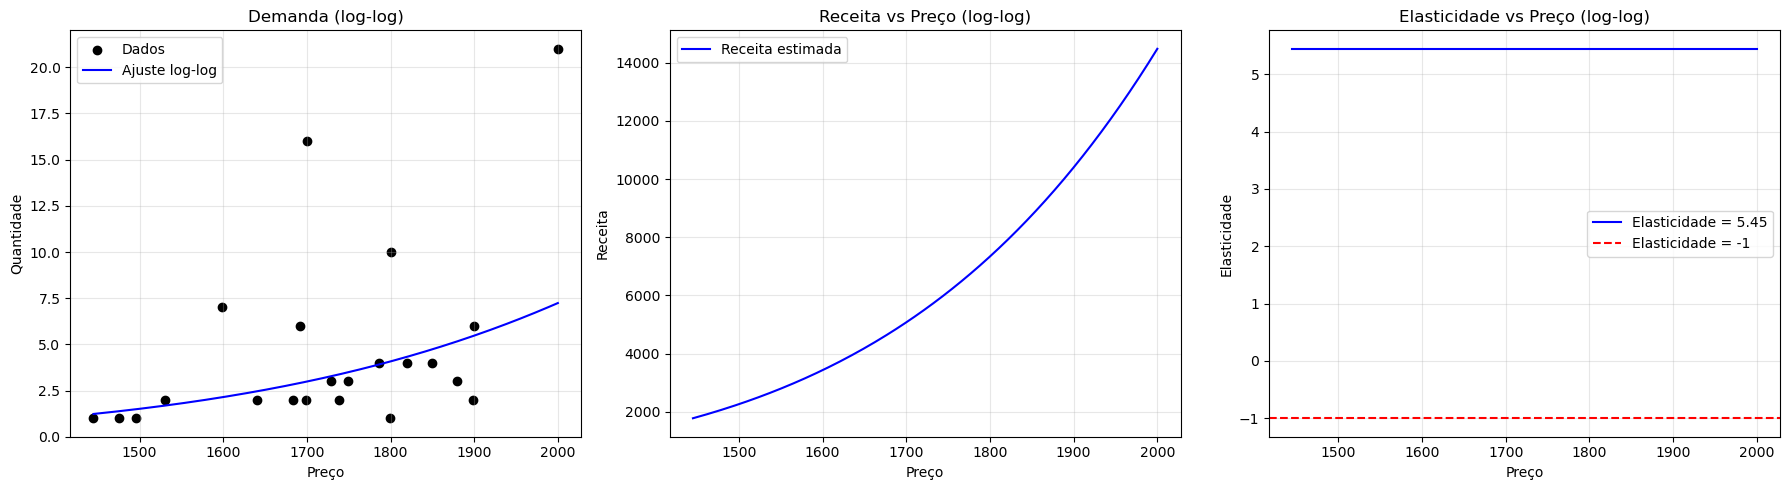

Resultados do ajuste log-log:
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     8.670
Date:                Tue, 23 Sep 2025   Prob (F-statistic):            0.00802
Time:                        21:31:11   Log-Likelihood:                -23.562
No. Observations:                  22   AIC:                             51.12
Df Residuals:                      20   BIC:                             53.31
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -39.4100 

In [65]:
df_log = df_demanda[(df_demanda['price'] > 0) & (df_demanda['quantidade'] > 0)].copy()
X = np.log(df_log['price'])
y = np.log(df_log['quantidade'])
X = sm.add_constant(X)

model_loglog = sm.OLS(y, X).fit()
beta0, beta1 = model_loglog.params  # intercepto e elasticidade

precos = np.linspace(df_log['price'].min(), df_log['price'].max(), 200)
quantidades_pred = np.exp(beta0 + beta1 * np.log(precos))
receita = precos * quantidades_pred
elasticidade = np.repeat(beta1, len(precos))  # constante no modelo log-log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Demanda
axes[0].scatter(df_log['price'], df_log['quantidade'], label="Dados", color="black")
axes[0].plot(precos, quantidades_pred, color="blue", label="Ajuste log-log")
axes[0].set_title("Demanda (log-log)")
axes[0].set_xlabel("Preço")
axes[0].set_ylabel("Quantidade")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Receita
axes[1].plot(precos, receita, color="blue", label="Receita estimada")
axes[1].set_title("Receita vs Preço (log-log)")
axes[1].set_xlabel("Preço")
axes[1].set_ylabel("Receita")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Elasticidade
axes[2].plot(precos, elasticidade, color="blue", label=f"Elasticidade = {beta1:.2f}")
axes[2].axhline(-1, color="red", linestyle="--", label="Elasticidade = -1")
axes[2].set_title("Elasticidade vs Preço (log-log)")
axes[2].set_xlabel("Preço")
axes[2].set_ylabel("Elasticidade")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Resultados do ajuste log-log:")
print(model_loglog.summary())
print(f"\nElasticidade-preço estimada (beta1): {beta1:.3f}")

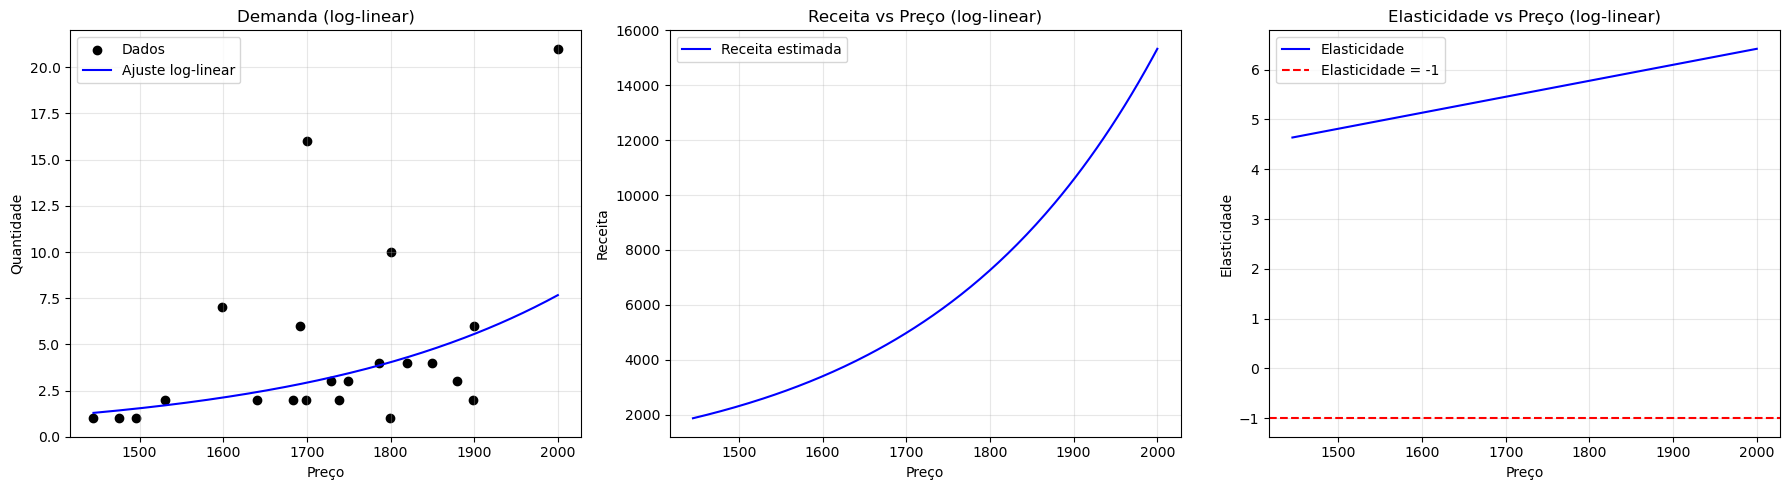

Resultados do ajuste log-linear:
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 23 Sep 2025   Prob (F-statistic):            0.00823
Time:                        21:31:22   Log-Likelihood:                -23.588
No. Observations:                  22   AIC:                             51.18
Df Residuals:                      20   BIC:                             53.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.38

In [66]:
df_loglin = df_demanda[(df_demanda['price'] > 0) & (df_demanda['quantidade'] > 0)].copy()  # remover valores não positivos
X = df_loglin['price']
y = np.log(df_loglin['quantidade'])
X = sm.add_constant(X)

model_loglin = sm.OLS(y, X).fit()
beta0, beta1 = model_loglin.params

precos = np.linspace(df_loglin['price'].min(), df_loglin['price'].max(), 200)
quantidades_pred = np.exp(beta0 + beta1 * precos)
receita = precos * quantidades_pred
elasticidade = beta1 * precos  # varia com o preço

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Demanda
axes[0].scatter(df_loglin['price'], df_loglin['quantidade'], label="Dados", color="black")
axes[0].plot(precos, quantidades_pred, color="blue", label="Ajuste log-linear")
axes[0].set_title("Demanda (log-linear)")
axes[0].set_xlabel("Preço")
axes[0].set_ylabel("Quantidade")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Receita
axes[1].plot(precos, receita, color="blue", label="Receita estimada")
axes[1].set_title("Receita vs Preço (log-linear)")
axes[1].set_xlabel("Preço")
axes[1].set_ylabel("Receita")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Elasticidade
axes[2].plot(precos, elasticidade, color="blue", label="Elasticidade")
axes[2].axhline(-1, color="red", linestyle="--", label="Elasticidade = -1")
axes[2].set_title("Elasticidade vs Preço (log-linear)")
axes[2].set_xlabel("Preço")
axes[2].set_ylabel("Elasticidade")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Resultados do ajuste log-linear:")
print(model_loglin.summary())